In [2]:
import os
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import scipy
from scipy.stats import entropy
from sklearn.decomposition import PCA
from scipy.optimize import curve_fit
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [39]:
tr = pd.read_csv('bearing_train_final.csv')
tr

,Sensor_1,Sensor_2,Sensor_3,Sensor_4,RUL
0,0.058287,0.071833,0.083235,0.043066,1.000000
1,0.058431,0.071900,0.083304,0.043115,0.999967
2,0.058427,0.071936,0.083305,0.043147,0.999933
3,0.058434,0.071990,0.083321,0.043181,0.999900
4,0.058254,0.072062,0.083367,0.043240,0.999867
...,...,...,...,...,...
26995,0.119958,0.077500,0.079234,0.050442,0.100137
26996,0.119803,0.077589,0.079228,0.050476,0.100103
26997,0.119848,0.077583,0.079244,0.050507,0.100070
26998,0.119426,0.077582,0.079230,0.050553,0.100037


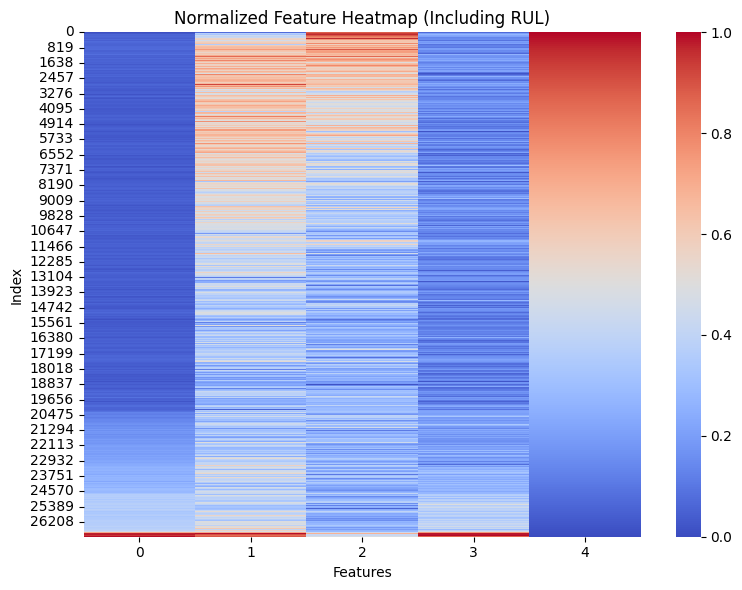

In [40]:
scaler = MinMaxScaler()
scaled = scaler.fit_transform(tr)

plt.figure(figsize=(8, 6))
sns.heatmap(
    scaled,
    cmap='coolwarm',
    cbar=True
)

plt.title("Normalized Feature Heatmap (Including RUL)")
plt.xlabel("Features")
plt.ylabel("Index")
plt.tight_layout()
plt.show()

=> RUL과 함께 비교하기 위해 정규화 거침

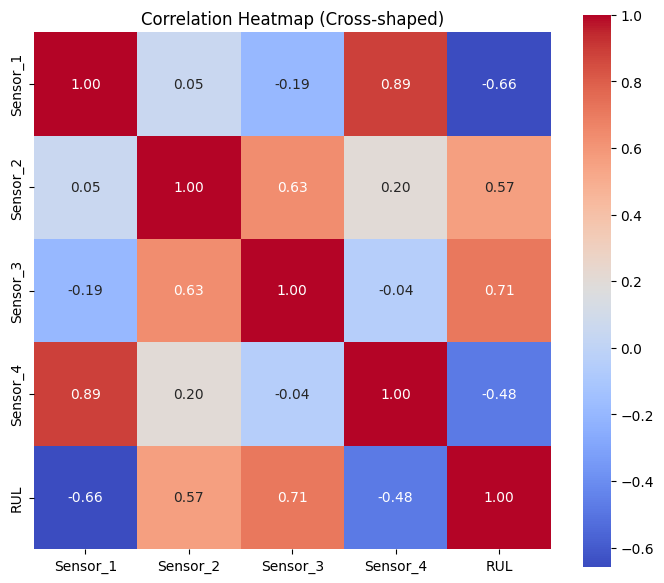

In [41]:
cols = ['Sensor_1', 'Sensor_2', 'Sensor_3', 'Sensor_4', 'RUL']

corr = tr[cols].corr()

plt.figure(figsize=(7, 6))
sns.heatmap(
    corr,
    annot=True,        # 숫자 표시
    fmt=".2f",
    cmap='coolwarm',
    square=True,       # 가로세로 정사각형
    cbar=True
)

plt.title("Correlation Heatmap (Cross-shaped)")
plt.tight_layout()
plt.show()

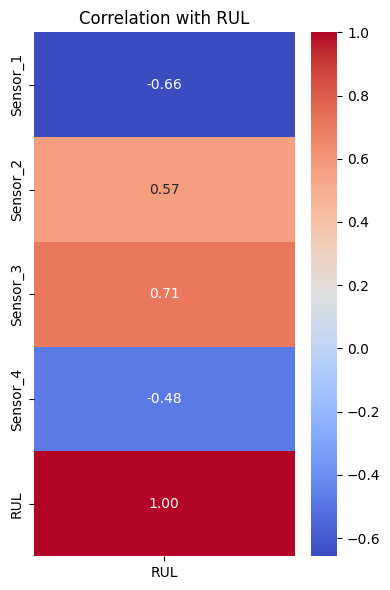

In [42]:
corr_rul = tr[cols].corr()[['RUL']]

plt.figure(figsize=(4, 6))
sns.heatmap(
    corr_rul,
    annot=True,
    cmap='coolwarm',
    fmt=".2f"
)

plt.title("Correlation with RUL")
plt.tight_layout()
plt.show()

=> 각 센서와 RUL의 상관관계 분석을 위한 히트맵

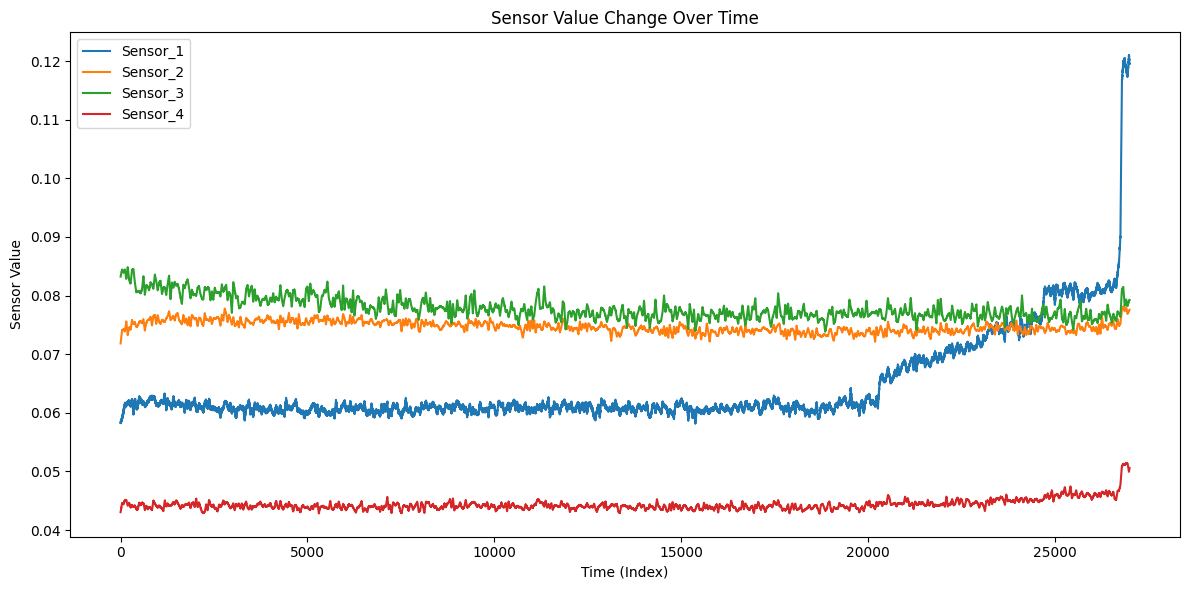

In [43]:
plt.figure(figsize=(12, 6))

for col in ['Sensor_1', 'Sensor_2', 'Sensor_3', 'Sensor_4']:
    plt.plot(tr.index, tr[col], label=col)

plt.xlabel("Time (Index)")
plt.ylabel("Sensor Value")
plt.title("Sensor Value Change Over Time")
plt.legend()
plt.tight_layout()
plt.show()

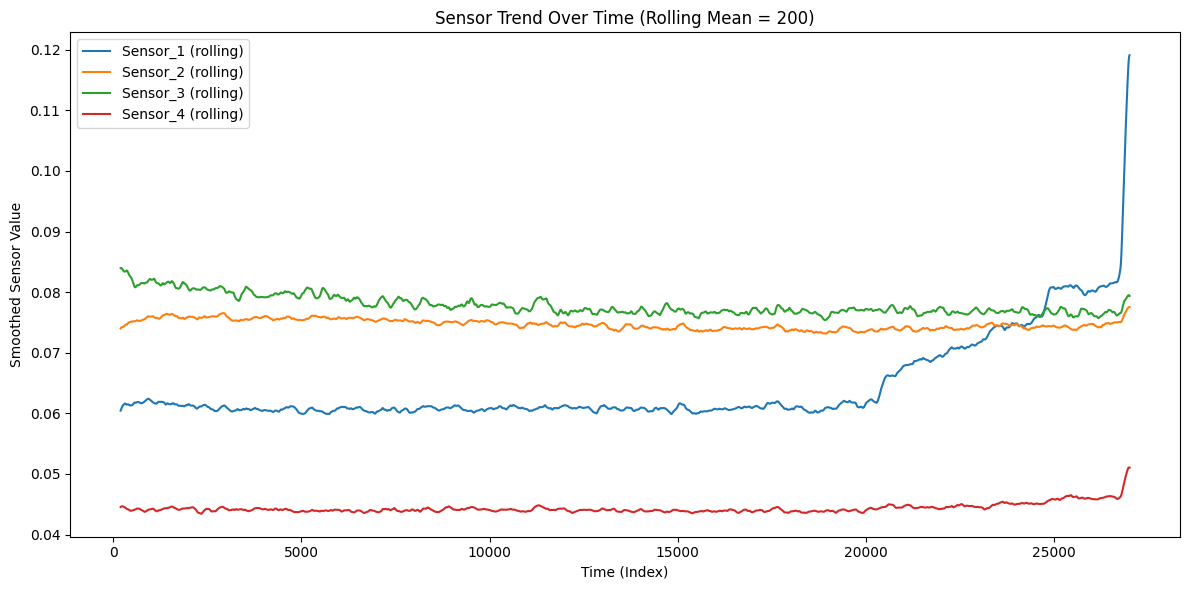

In [44]:
window = 200  # 상황에 맞게 50~500 조절

plt.figure(figsize=(12, 6))

for col in ['Sensor_1', 'Sensor_2', 'Sensor_3', 'Sensor_4']:
    plt.plot(
        tr.index,
        tr[col].rolling(window).mean(),
        label=f"{col} (rolling)"
    )

plt.xlabel("Time (Index)")
plt.ylabel("Smoothed Sensor Value")
plt.title(f"Sensor Trend Over Time (Rolling Mean = {window})")
plt.legend()
plt.tight_layout()
plt.show()

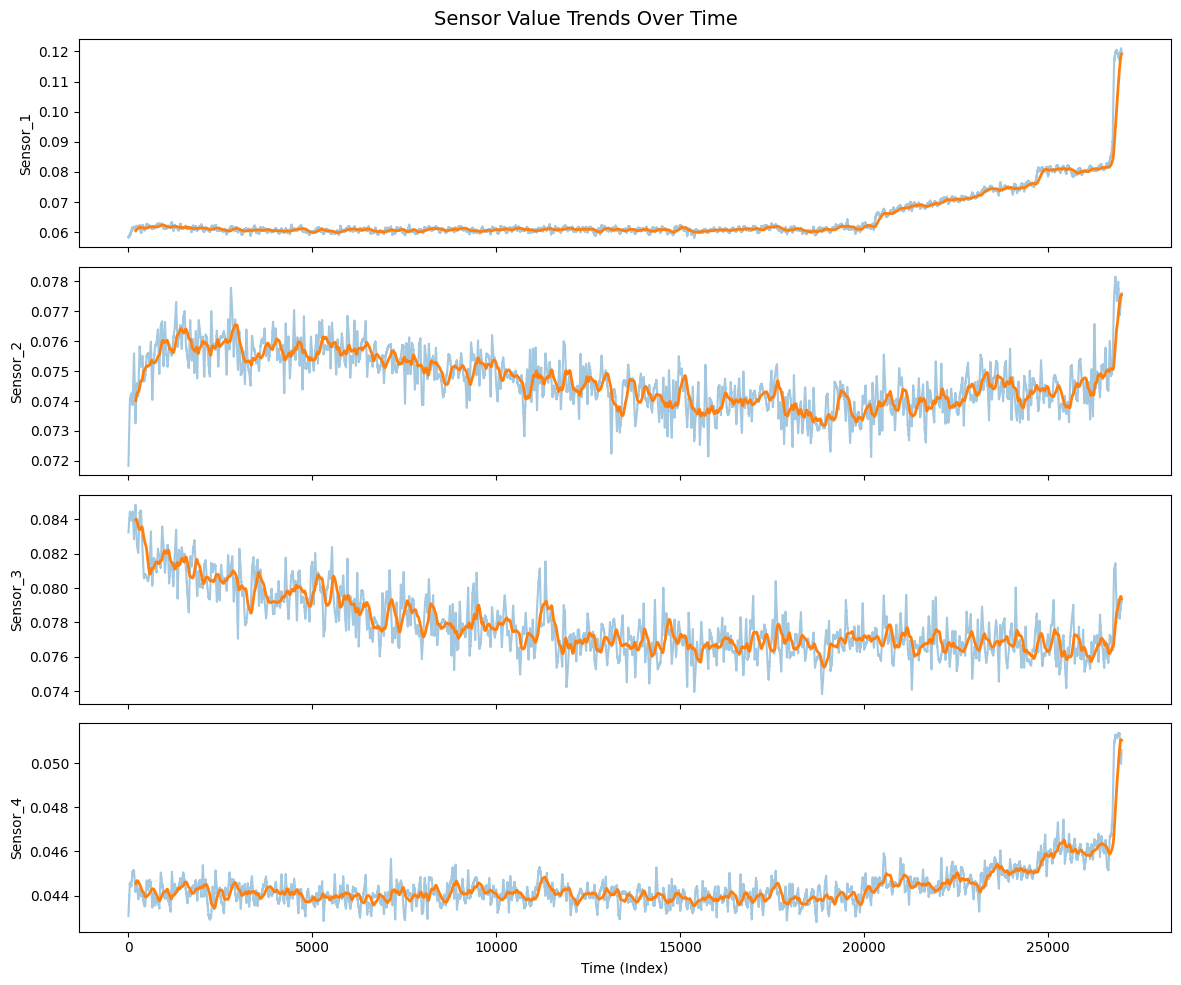

In [45]:
fig, axes = plt.subplots(4, 1, figsize=(12, 10), sharex=True)

sensors = ['Sensor_1', 'Sensor_2', 'Sensor_3', 'Sensor_4']

for i, col in enumerate(sensors):
    axes[i].plot(tr.index, tr[col], alpha=0.4)
    axes[i].plot(
        tr.index,
        tr[col].rolling(200).mean(),
        linewidth=2
    )
    axes[i].set_ylabel(col)

axes[-1].set_xlabel("Time (Index)")
fig.suptitle("Sensor Value Trends Over Time", fontsize=14)
plt.tight_layout()
plt.show()

=> 25000행 지나면서부터 튀는 값 발생
 - 20000행 근처에서 센서1의 값이 우상햔하기 시작한 것으로 보아 열화 상태, 이에 다른 센서 함께 영향 받은 것으로 추정

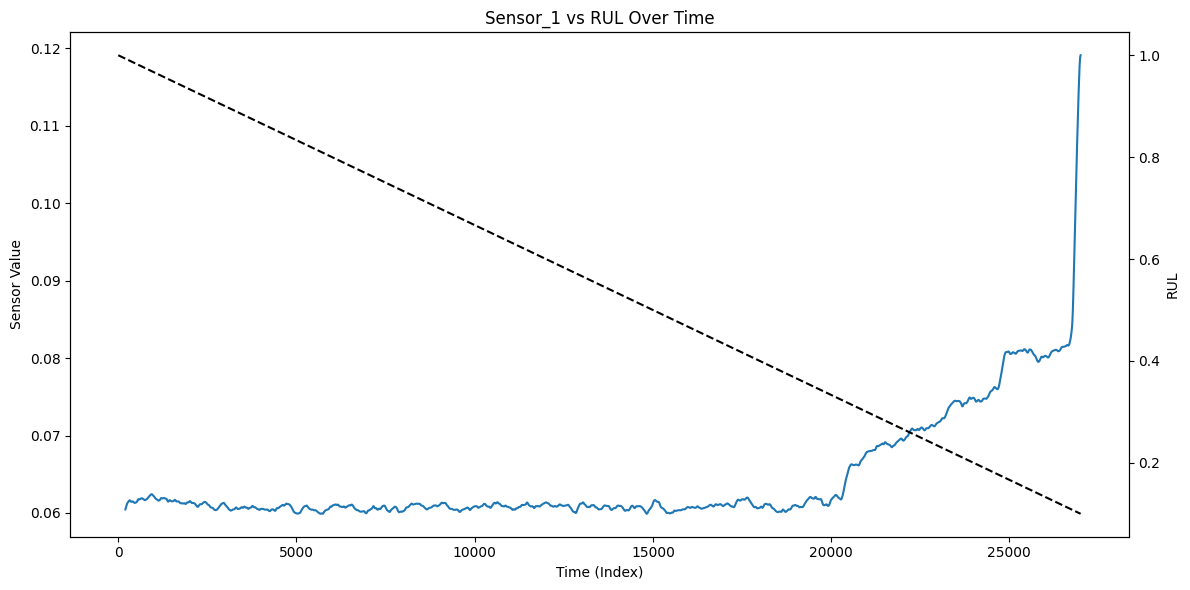

In [46]:
fig, ax1 = plt.subplots(figsize=(12, 6))

ax1.plot(tr.index, tr['Sensor_1'].rolling(200).mean(), label='Sensor_1')
ax1.set_ylabel("Sensor Value")

ax2 = ax1.twinx()
ax2.plot(tr.index, tr['RUL'], color='black', linestyle='--', label='RUL')
ax2.set_ylabel("RUL")

ax1.set_xlabel("Time (Index)")
plt.title("Sensor_1 vs RUL Over Time")
plt.tight_layout()
plt.show()

=> ax1.plot(tr.index, tr['Sensor_4'].rolling(200).mean(), label='Sensor_1')에서 센서 번호를 바꿔가면서 확인하면 1과 4번 센서에서 열화 및 고장 발생, 2와 3번 센서는 RUL에 영향 없는 듯?

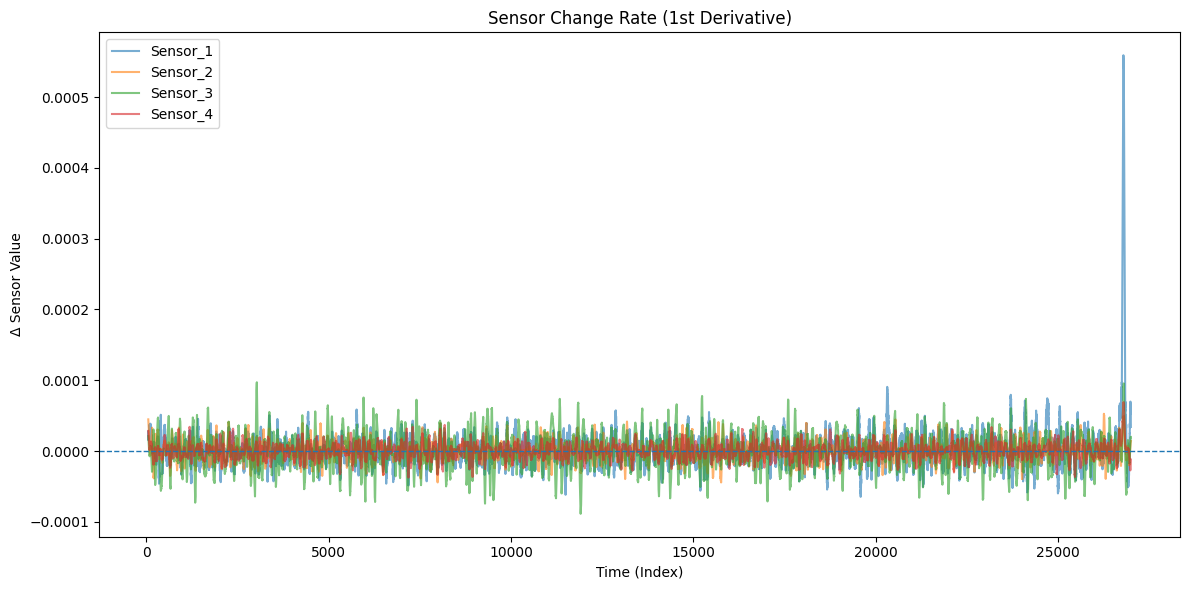

In [47]:
sensor_cols = ['Sensor_1', 'Sensor_2', 'Sensor_3', 'Sensor_4']

window = 50
trd = tr[sensor_cols].diff().rolling(window).mean()

plt.figure(figsize=(12, 6))

for col in sensor_cols:
    plt.plot(trd.index, trd[col], label=col, alpha = 0.6)

plt.axhline(0, linestyle='--', linewidth=1)
plt.xlabel("Time (Index)")
plt.ylabel("Δ Sensor Value")
plt.title("Sensor Change Rate (1st Derivative)")
plt.legend()
plt.tight_layout()
plt.show()

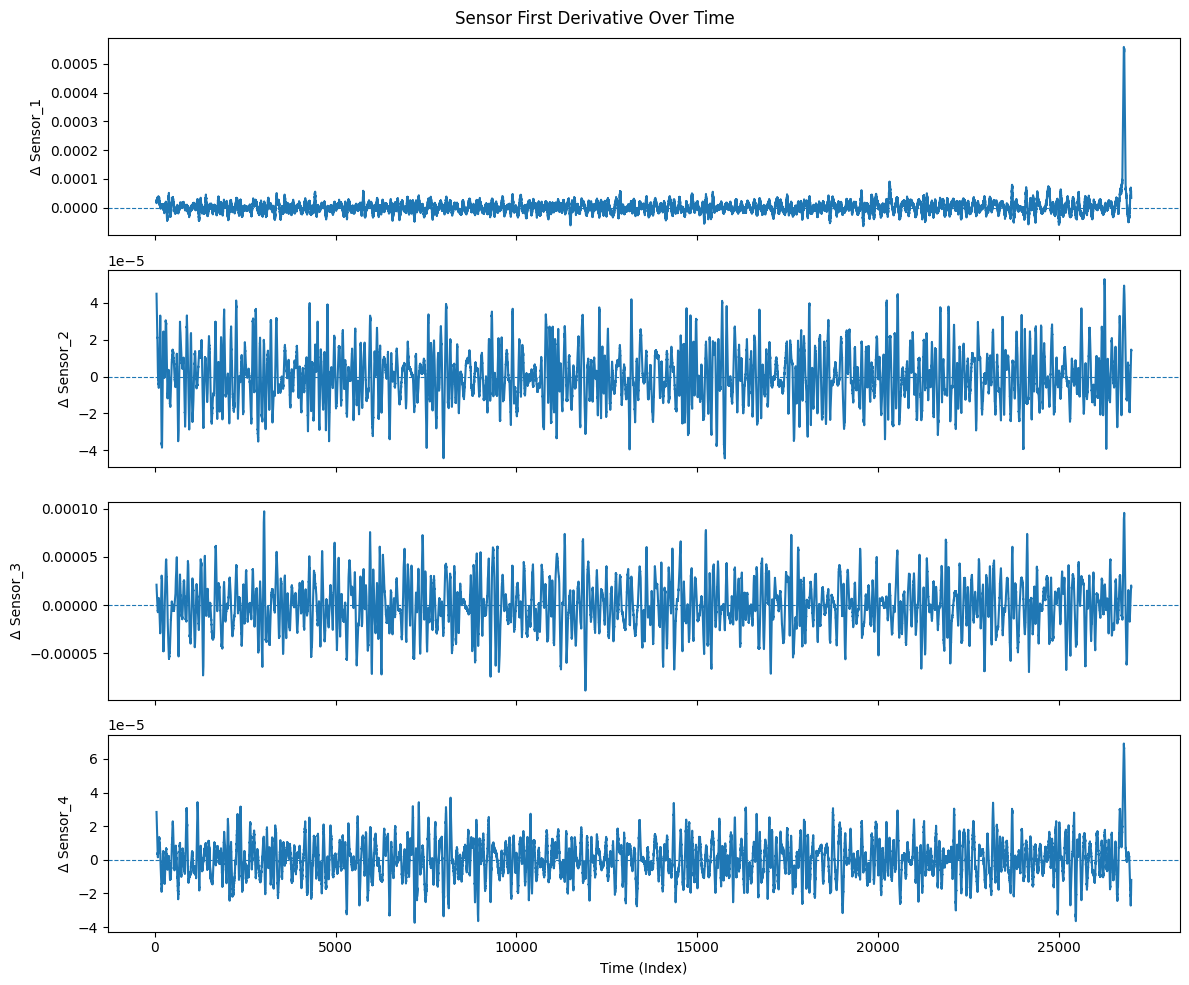

In [48]:
fig, axes = plt.subplots(4, 1, figsize=(12, 10), sharex=True)

for i, col in enumerate(sensor_cols):
    axes[i].plot(trd.index, trd[col])
    axes[i].axhline(0, linestyle='--', linewidth=0.8)
    axes[i].set_ylabel(f"Δ {col}")

axes[-1].set_xlabel("Time (Index)")
fig.suptitle("Sensor First Derivative Over Time")
plt.tight_layout()
plt.show()

=> 각 센서에 대한 미분값 그래프화한 것.

<해석>
- Sensor 1: 열화 누적으로 임계점 도달 후 급격한 상태 변화
- Sensor 4: 열화 진행 중 고장 이벤트 발생
- Sensor 2·3: 열화와 직접적 연관성 낮은 보조 센서

In [49]:
# sensor_cols = ['Sensor_1', 'Sensor_2', 'Sensor_3', 'Sensor_4']
corr = tr[sensor_cols + ['RUL']].corr()
corr_rul = corr[['RUL']].drop('RUL')
print(corr_rul)

               RUL
Sensor_1 -0.657716
Sensor_2  0.565459
Sensor_3  0.708616
Sensor_4 -0.477193


> - |corr| ≥ 0.5 → RUL과 강한 관계
> - 0.2 ~ 0.5 → 약~중간
> - < 0.2 → 거의 무관

In [50]:
trd

,Sensor_1,Sensor_2,Sensor_3,Sensor_4
0,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN
...,...,...,...,...
26995,0.000051,0.000013,0.000020,-0.000017
26996,0.000048,0.000015,0.000020,-0.000017
26997,0.000046,0.000015,0.000020,-0.000016
26998,0.000038,0.000014,0.000020,-0.000014


In [51]:
d_tr = tr[sensor_cols].diff()

# 변화 강도 (절댓값)
abs_d = d_tr.abs()

corr_abs = pd.concat([abs_d, tr['RUL']], axis=1).corr()

corr_abs_rul = corr_abs[['RUL']].drop('RUL')

print(corr_abs_rul)

               RUL
Sensor_1 -0.016546
Sensor_2  0.014803
Sensor_3  0.028111
Sensor_4 -0.001034


> - 열화 말기 → 센서 변화율 커짐
> - RUL ↓ ↔ |미분| ↑
> - 그래서 음의 상관이 자주 나옴

In [52]:
lags = range(0, 500, 50)  # 최대 500 step까지

results = {}

for col in sensor_cols:
    vals = []
    for lag in lags:
        vals.append(
            tr[col].shift(lag).corr(tr['RUL'])
        )
    results[col] = vals

lag_corr = pd.DataFrame(results, index=lags)
print(lag_corr)

     Sensor_1  Sensor_2  Sensor_3  Sensor_4
0   -0.657716  0.565459  0.708616 -0.477193
50  -0.667066  0.579938  0.712467 -0.476752
100 -0.677538  0.596150  0.716245 -0.480557
150 -0.692634  0.613645  0.720080 -0.486225
200 -0.711163  0.634291  0.729642 -0.494704
250 -0.719712  0.644942  0.733888 -0.496692
300 -0.718807  0.648180  0.734338 -0.492522
350 -0.717248  0.653628  0.734873 -0.488486
400 -0.715500  0.654618  0.734250 -0.486205
450 -0.713734  0.659098  0.734350 -0.482310


> lag > 0 에서 상관 ↑
> → 고장 조기 감지 센서

> lag 0 에서만 높음
> → 단순 동조 센서

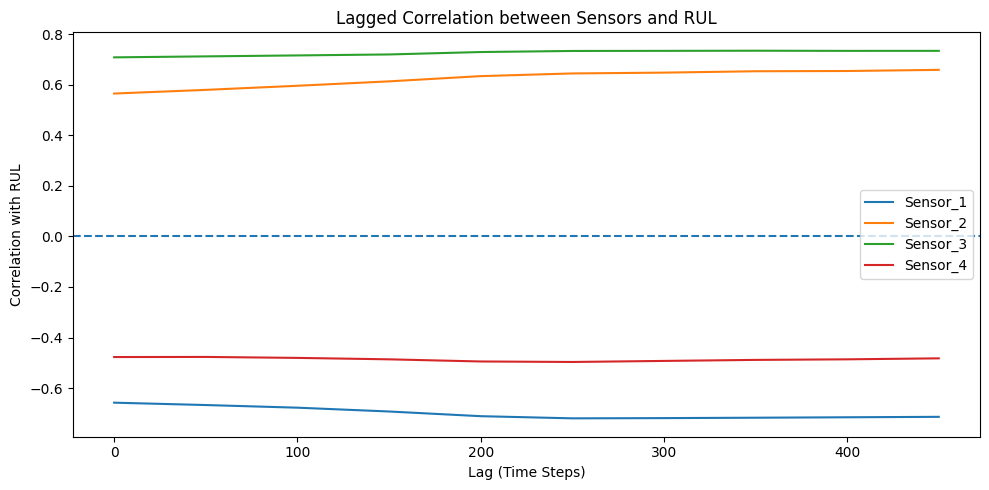

In [53]:
plt.figure(figsize=(10, 5))

for col in sensor_cols:
    plt.plot(lag_corr.index, lag_corr[col], label=col)

plt.axhline(0, linestyle='--')
plt.xlabel("Lag (Time Steps)")
plt.ylabel("Correlation with RUL")
plt.title("Lagged Correlation between Sensors and RUL")
plt.legend()
plt.tight_layout()
plt.show()

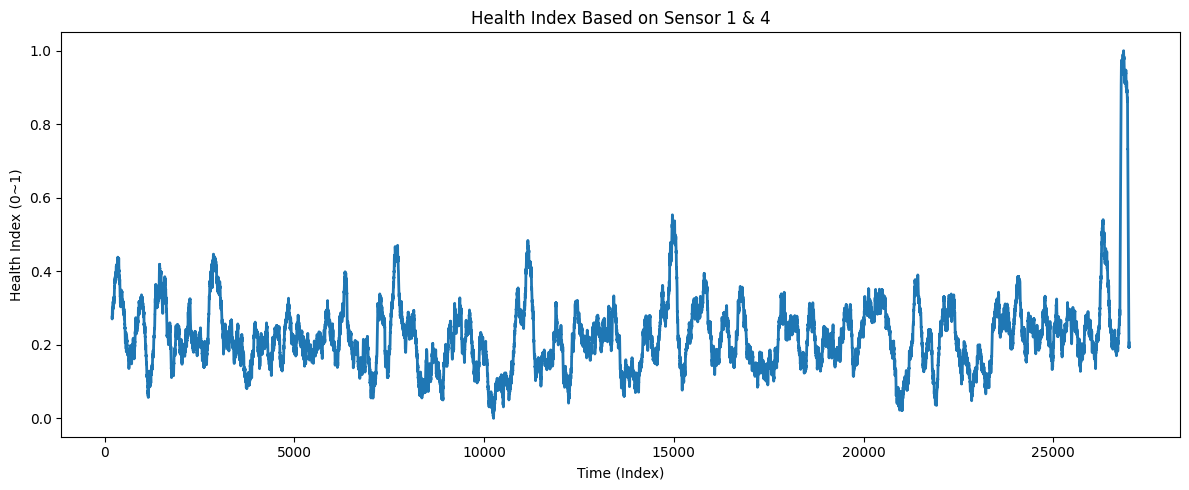

In [62]:
sensors = ['Sensor_1', 'Sensor_2']
tr2 = tr.copy()

d = tr[sensors].diff()
abs_d = d.abs()

window = 200
abs_d_smooth = abs_d.rolling(window).mean()

HI_raw = abs_d_smooth.mean(axis=1)
HI = (HI_raw - HI_raw.min()) / (HI_raw.max() - HI_raw.min())
tr2['Health_Index'] = HI


plt.figure(figsize=(12, 5))
plt.plot(tr2.index, tr2['Health_Index'], label='Health Index', linewidth=2)
plt.xlabel("Time (Index)")
plt.ylabel("Health Index (0~1)")
plt.title("Health Index Based on Sensor 1 & 4")
plt.tight_layout()
plt.show()

> - 0 근처 → 건강
> - 1 근처 → 고장 임박
> - 단조 증가면 잘 만든 HI

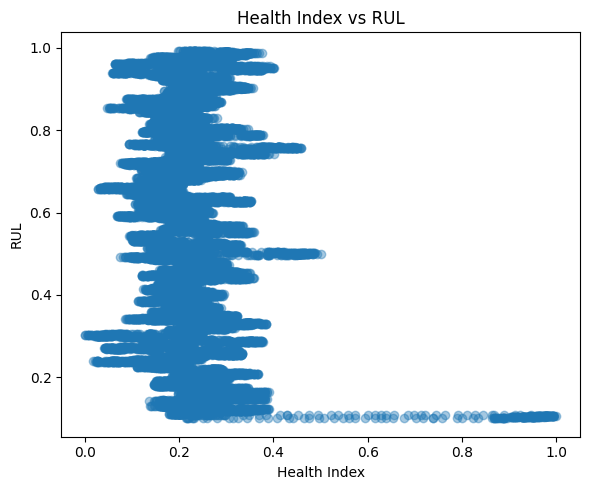

In [60]:
plt.figure(figsize=(6, 5))
plt.scatter(tr2['Health_Index'], tr2['RUL'], alpha=0.4)
plt.xlabel("Health Index")
plt.ylabel("RUL")
plt.title("Health Index vs RUL")
plt.tight_layout()
plt.show()

=> 시간이 증가함에 따라 RUL이 점차 감소하고, health index가 마지막에 튀는 값을 가지므로 고장 발생 가능성 농후

In [57]:
abs_d

,Sensor_1,Sensor_3
0,NaN,NaN
1,0.000144,0.000068
2,0.000004,0.000001
3,0.000007,0.000015
4,0.000181,0.000046
...,...,...
26995,0.000074,0.000005
26996,0.000155,0.000006
26997,0.000045,0.000016
26998,0.000422,0.000014


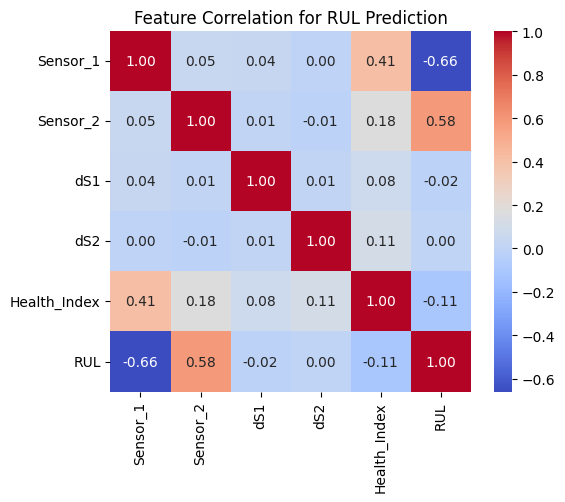

In [63]:
features = pd.DataFrame(index=tr.index)

# 원본 센서 (선별)
features['Sensor_1'] = tr2['Sensor_1']
features['Sensor_2'] = tr2['Sensor_2']

# 변화 강도
features['dS1'] = abs_d['Sensor_1']
features['dS2'] = abs_d['Sensor_2']

# Health Index
features['Health_Index'] = tr2['Health_Index']

# RUL (타겟)
target = tr2['RUL']

features = features.dropna()
target = target.loc[features.index]

plt.figure(figsize=(6, 5))
sns.heatmap(
    features.join(target).corr(),
    annot=True,
    fmt=".2f",
    cmap='coolwarm',
    square=True
)
plt.title("Feature Correlation for RUL Prediction")
plt.tight_layout()
plt.show()

### ==============================
웨이블렛 변환을 위한 그래프 작성

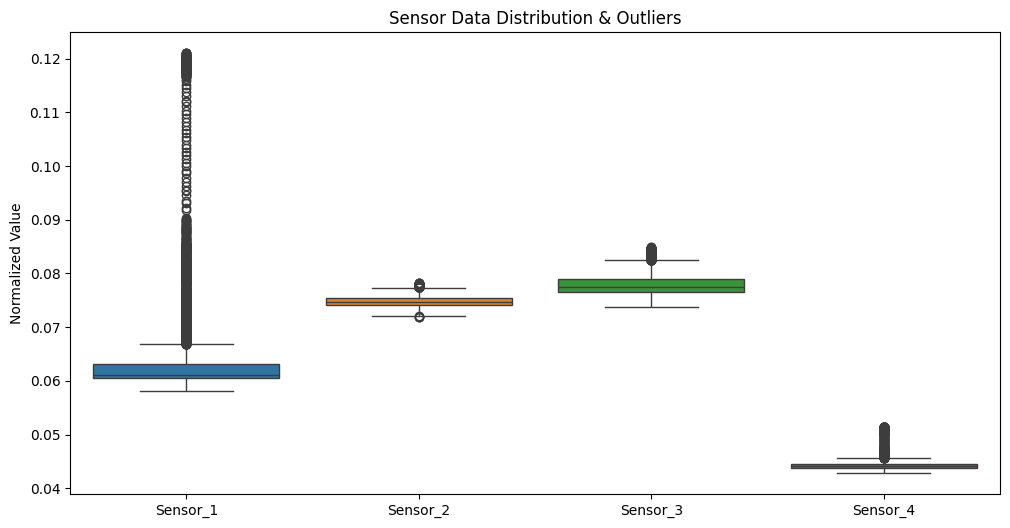

In [51]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=tr[sensor_cols])
plt.title('Sensor Data Distribution & Outliers')
plt.ylabel('Normalized Value')
plt.show()

In [107]:
def get_outlier_indices(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    
    # 일반적인 이상치 기준 (1.5 * IQR)
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # 이상치 위치 반환
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)].index
    return outliers, lower_bound, upper_bound

# 예: Sensor_1의 이상치 확인
outliers_s1, lb, ub = get_outlier_indices(tr2, 'Sensor_1')
print(f"Sensor_1에서 발견된 이상치 개수: {len(outliers_s1)} ({len(outliers_s1)/len(tr2)*100:.2f}%)")
# 예: Sensor_2의 이상치 확인
outliers_s1, lb, ub = get_outlier_indices(tr2, 'Sensor_2')
print(f"Sensor_2에서 발견된 이상치 개수: {len(outliers_s1)} ({len(outliers_s1)/len(tr2)*100:.2f}%)")
# 예: Sensor_3의 이상치 확인
outliers_s1, lb, ub = get_outlier_indices(tr2, 'Sensor_3')
print(f"Sensor_3에서 발견된 이상치 개수: {len(outliers_s1)} ({len(outliers_s1)/len(tr2)*100:.2f}%)")
# 예: Sensor_4의 이상치 확인
outliers_s1, lb, ub = get_outlier_indices(tr2, 'Sensor_4')
print(f"Sensor_4에서 발견된 이상치 개수: {len(outliers_s1)} ({len(outliers_s1)/len(tr2)*100:.2f}%)")

Sensor_1에서 발견된 이상치 개수: 6274 (23.24%)
Sensor_2에서 발견된 이상치 개수: 184 (0.68%)
Sensor_3에서 발견된 이상치 개수: 498 (1.84%)
Sensor_4에서 발견된 이상치 개수: 1890 (7.00%)


#### * 센서 2, 3 추가

In [103]:
def get_outliers(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return df[(df[col] < lower_bound) | (df[col] > upper_bound)].index

In [104]:
outliers_s2 = get_outliers(tr2, 'Sensor_2')
outliers_s3 = get_outliers(tr2, 'Sensor_3')

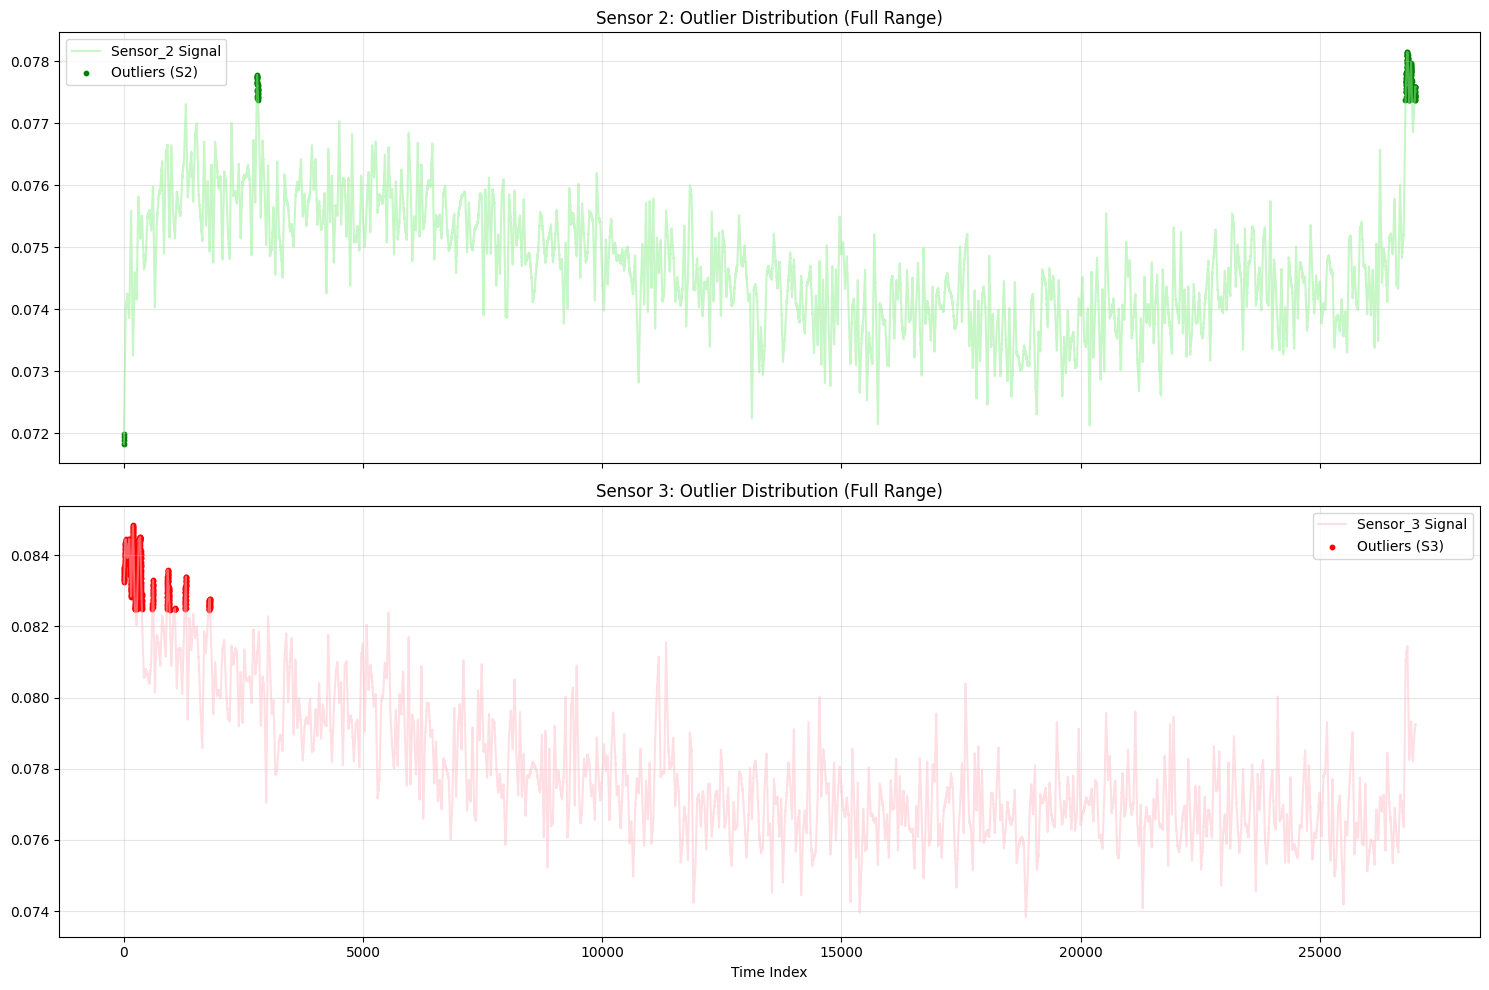

In [105]:
fig, ax = plt.subplots(2, 1, figsize=(15, 10), sharex=True)

# Sensor 2 그래프
ax[0].plot(tr2.index, tr2['Sensor_2'], color='lightgreen', alpha=0.5, label='Sensor_2 Signal')
ax[0].scatter(outliers_s2, tr2.loc[outliers_s2, 'Sensor_2'], color='green', s=10, label='Outliers (S2)')
ax[0].set_title('Sensor 2: Outlier Distribution (Full Range)')
ax[0].legend()
ax[0].grid(True, alpha=0.3)

# Sensor 3 그래프
ax[1].plot(tr2.index, tr2['Sensor_3'], color='pink', alpha=0.5, label='Sensor_3 Signal')
ax[1].scatter(outliers_s3, tr2.loc[outliers_s3, 'Sensor_3'], color='red', s=10, label='Outliers (S3)')
ax[1].set_title('Sensor 3: Outlier Distribution (Full Range)')
ax[1].legend()
ax[1].grid(True, alpha=0.3)

plt.xlabel('Time Index')
plt.tight_layout()
plt.show()

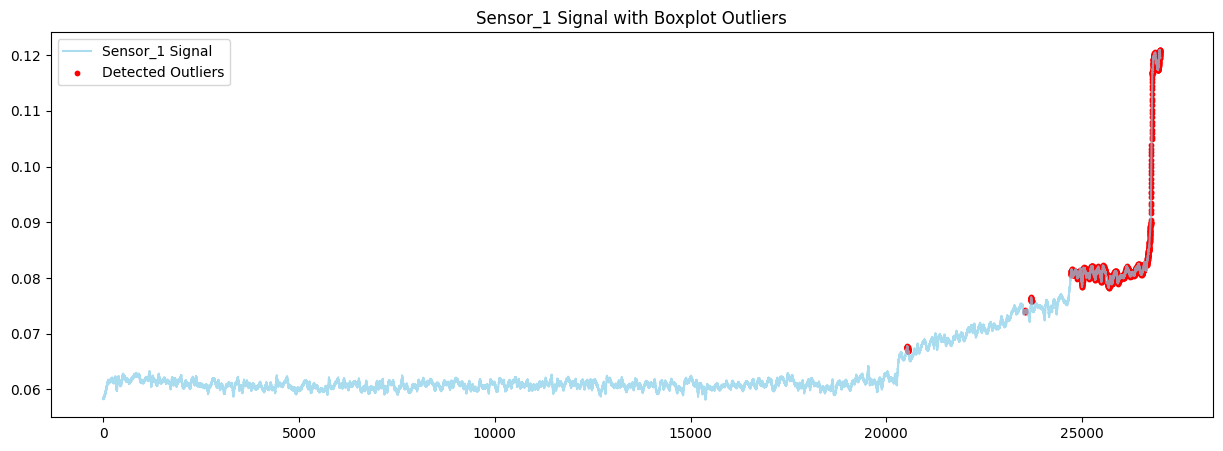

In [ ]:
plt.figure(figsize=(15, 5))
plt.plot(tr2['Sensor_1'], label='Sensor_1 Signal', color='skyblue', alpha=0.7)
plt.scatter(outliers_s1, tr2.loc[outliers_s1, 'Sensor_1'], color='red', s=10, label='Detected Outliers')
plt.title('Sensor_1 Signal with Boxplot Outliers')
plt.legend()2
plt.show()

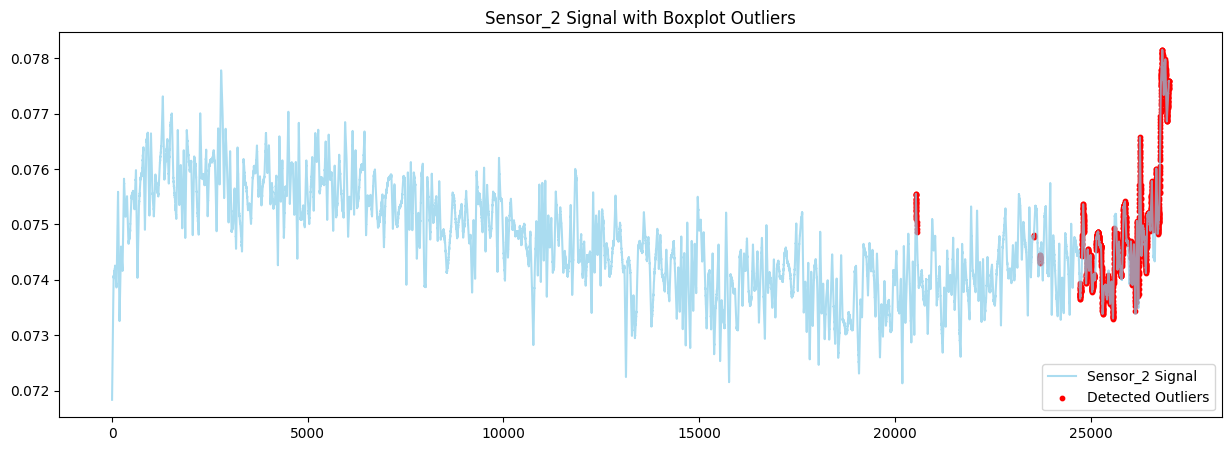

In [60]:
plt.figure(figsize=(15, 5))
plt.plot(tr2['Sensor_2'], label='Sensor_2 Signal', color='skyblue', alpha=0.7)
plt.scatter(outliers_s1, tr2.loc[outliers_s1, 'Sensor_2'], color='red', s=10, label='Detected Outliers')
plt.title('Sensor_2 Signal with Boxplot Outliers')
plt.legend()
plt.show()

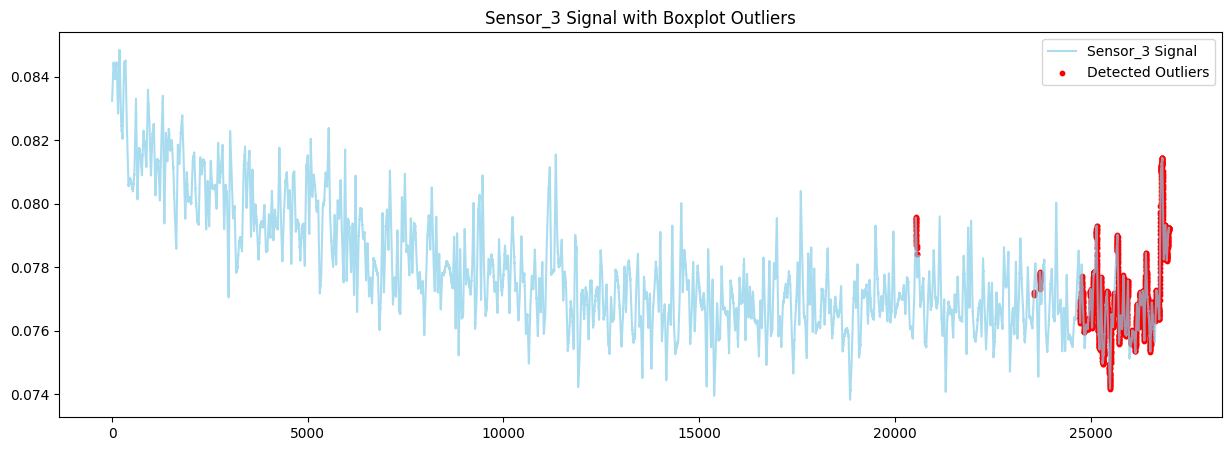

In [61]:
plt.figure(figsize=(15, 5))
plt.plot(tr2['Sensor_3'], label='Sensor_3 Signal', color='skyblue', alpha=0.7)
plt.scatter(outliers_s1, tr2.loc[outliers_s1, 'Sensor_3'], color='red', s=10, label='Detected Outliers')
plt.title('Sensor_3 Signal with Boxplot Outliers')
plt.legend()
plt.show()

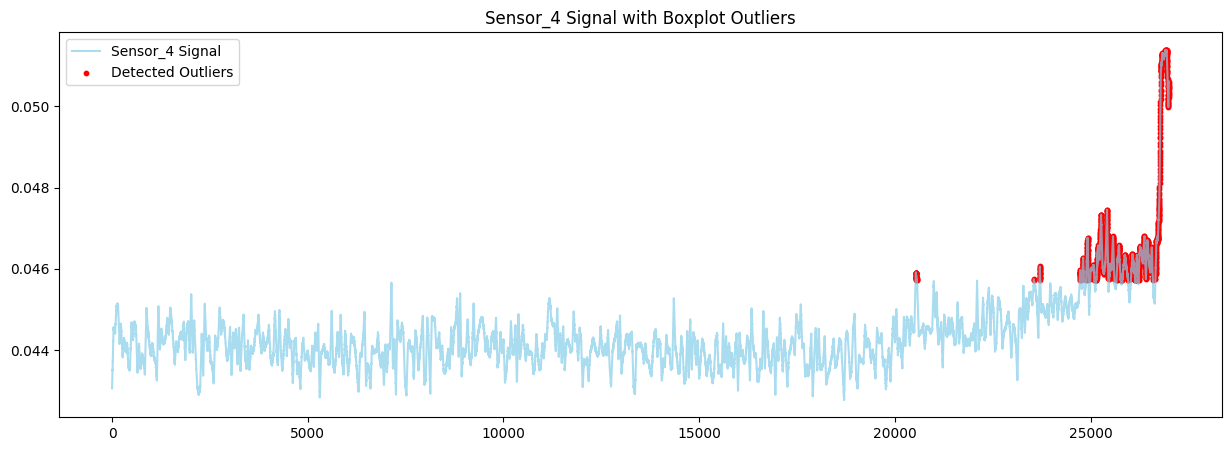

In [62]:
plt.figure(figsize=(15, 5))
plt.plot(tr2['Sensor_4'], label='Sensor_4 Signal', color='skyblue', alpha=0.7)
plt.scatter(outliers_s1, tr2.loc[outliers_s1, 'Sensor_4'], color='red', s=10, label='Detected Outliers')
plt.title('Sensor_4 Signal with Boxplot Outliers')
plt.legend()
plt.show()

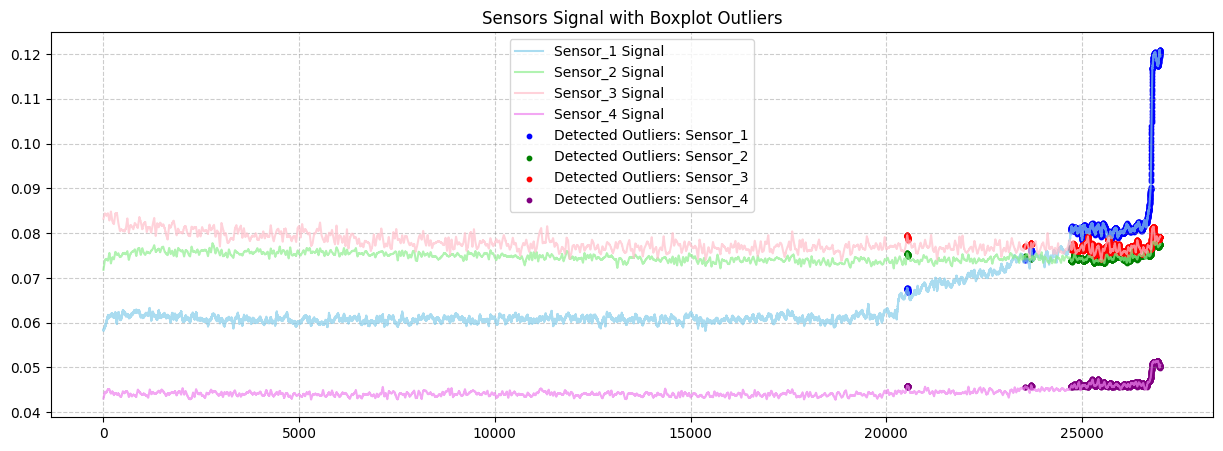

In [74]:
plt.figure(figsize=(15, 5))
plt.plot(tr2['Sensor_1'], label='Sensor_1 Signal', color='skyblue', alpha=0.7)
plt.plot(tr2['Sensor_2'], label='Sensor_2 Signal', color='lightgreen', alpha=0.7)
plt.plot(tr2['Sensor_3'], label='Sensor_3 Signal', color='pink', alpha=0.7)
plt.plot(tr2['Sensor_4'], label='Sensor_4 Signal', color='violet', alpha=0.7)
plt.scatter(outliers_s1, tr2.loc[outliers_s1, 'Sensor_1'], color='blue', s=10, label='Detected Outliers: Sensor_1')
plt.scatter(outliers_s1, tr2.loc[outliers_s1, 'Sensor_2'], color='green', s=10, label='Detected Outliers: Sensor_2')
plt.scatter(outliers_s1, tr2.loc[outliers_s1, 'Sensor_3'], color='red', s=10, label='Detected Outliers: Sensor_3')
plt.scatter(outliers_s1, tr2.loc[outliers_s1, 'Sensor_4'], color='purple', s=10, label='Detected Outliers: Sensor_4')
plt.title('Sensors Signal with Boxplot Outliers')
plt.grid(color = 'grey', linestyle='--', alpha = 0.4)
plt.legend()
plt.show()

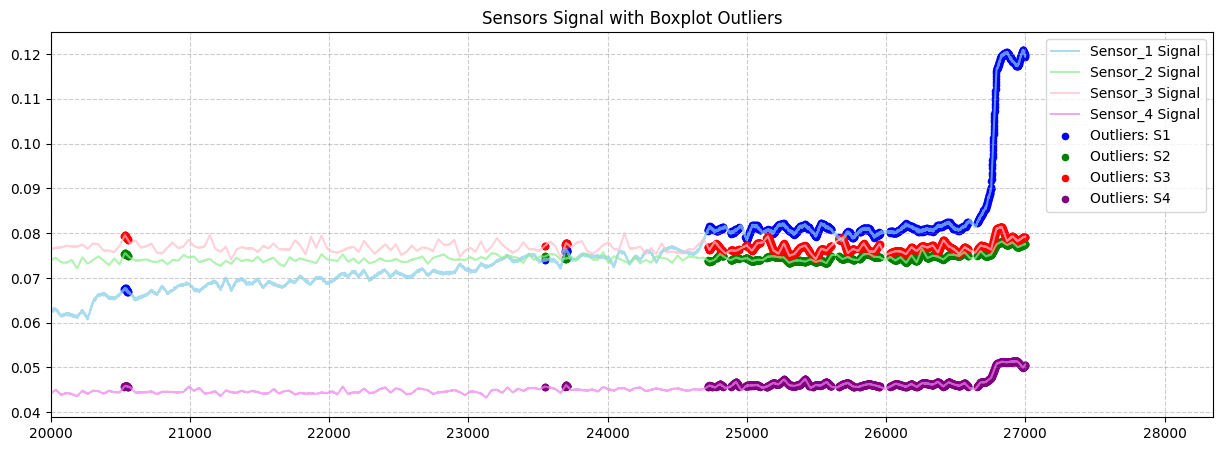

In [73]:
plt.figure(figsize=(15, 5))
plt.plot(tr2['Sensor_1'], label='Sensor_1 Signal', color='skyblue', alpha=0.7)
plt.plot(tr2['Sensor_2'], label='Sensor_2 Signal', color='lightgreen', alpha=0.7)
plt.plot(tr2['Sensor_3'], label='Sensor_3 Signal', color='pink', alpha=0.7)
plt.plot(tr2['Sensor_4'], label='Sensor_4 Signal', color='violet', alpha=0.7)
plt.scatter(outliers_s1, tr2.loc[outliers_s1, 'Sensor_1'], color='blue', s=20, label='Outliers: S1')
plt.scatter(outliers_s1, tr2.loc[outliers_s1, 'Sensor_2'], color='green', s=20, label='Outliers: S2')
plt.scatter(outliers_s1, tr2.loc[outliers_s1, 'Sensor_3'], color='red', s=20, label='Outliers: S3')
plt.scatter(outliers_s1, tr2.loc[outliers_s1, 'Sensor_4'], color='purple', s=20, label='Outliers: S4')
plt.xlim(left=20000)
plt.title('Sensors Signal with Boxplot Outliers')
plt.grid(color = 'grey', linestyle='--', alpha = 0.4)
plt.legend()
plt.show()

## =======================================
모델 제작 부분

In [77]:
X = tr2[['Health_Index']].dropna()
y = tr2.loc[X.index, 'RUL']

split = int(len(X) * 0.8)

X_train = X.iloc[:split]
X_test  = X.iloc[split:]

y_train = y.iloc[:split]
y_test  = y.iloc[split:]

model = LinearRegression()
model.fit(X_train, y_train)
y_pred_train = model.predict(X_train)
y_pred_test  = model.predict(X_test)


mae = mean_absolute_error(y_test, y_pred_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))

print(f"MAE : {mae:.3f}")
print(f"RMSE: {rmse:.3f}")

MAE : 0.452
RMSE: 0.456


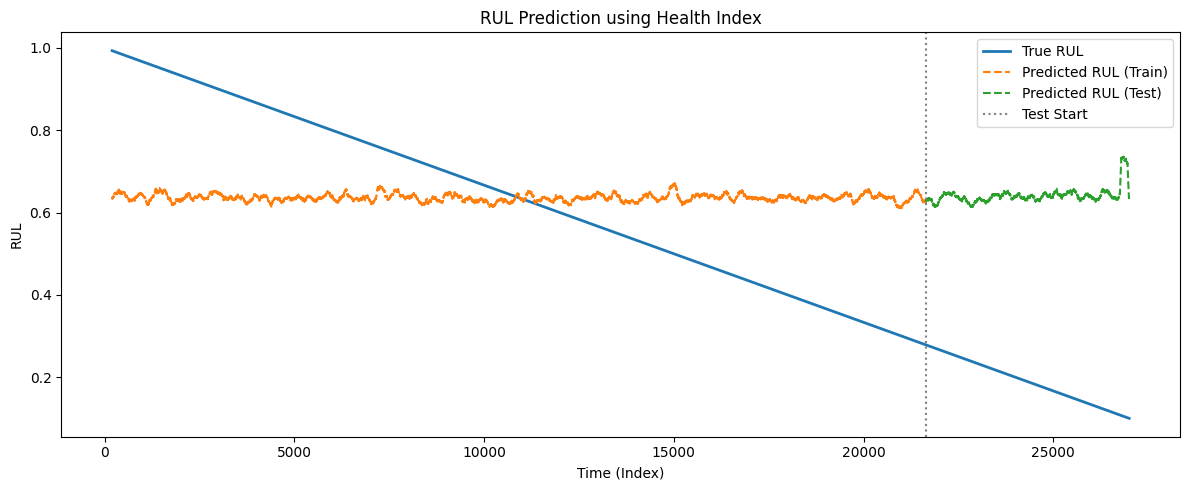

In [78]:
plt.figure(figsize=(12, 5))

plt.plot(y.index, y, label='True RUL', linewidth=2)
plt.plot(X_train.index, y_pred_train, '--', label='Predicted RUL (Train)')
plt.plot(X_test.index, y_pred_test, '--', label='Predicted RUL (Test)')

plt.axvline(X_test.index[0], color='gray', linestyle=':', label='Test Start')

plt.xlabel("Time (Index)")
plt.ylabel("RUL")
plt.title("RUL Prediction using Health Index")
plt.legend()
plt.tight_layout()
plt.show()

c:\Users\user\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


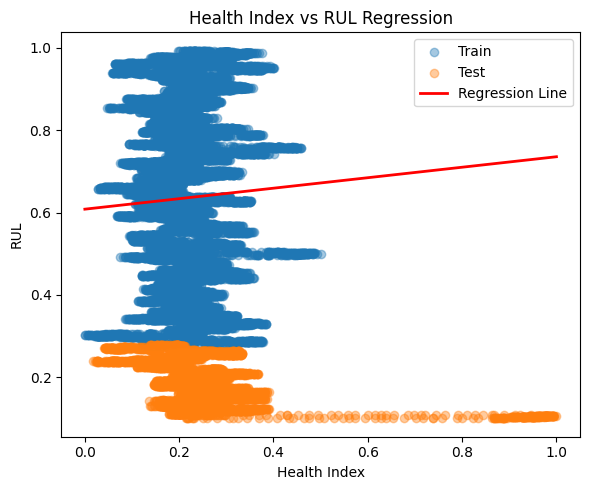

In [79]:
plt.figure(figsize=(6, 5))

plt.scatter(X_train['Health_Index'], y_train, alpha=0.4, label='Train')
plt.scatter(X_test['Health_Index'], y_test, alpha=0.4, label='Test')

x_line = np.linspace(0, 1, 100).reshape(-1, 1)
y_line = model.predict(x_line)

plt.plot(x_line, y_line, color='red', linewidth=2, label='Regression Line')

plt.xlabel("Health Index")
plt.ylabel("RUL")
plt.title("Health Index vs RUL Regression")
plt.legend()
plt.tight_layout()
plt.show()

### 이상하다
- health index를 누적식으로 하지 않으면 위와 같은 애매한 그래프
- 누적식으로 바꿔볼까?

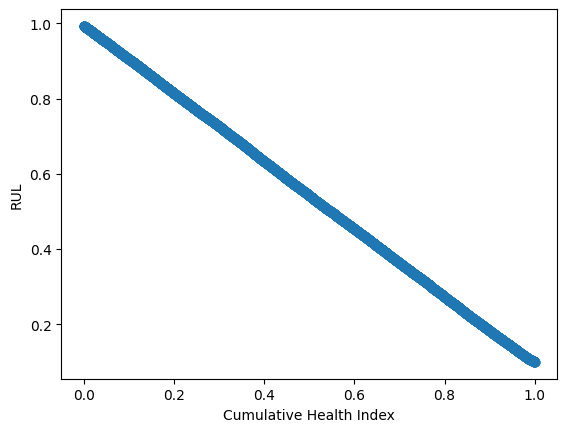

In [81]:
HI_cum = abs_d_smooth.mean(axis=1).cumsum()

# 정규화
HI_cum = (HI_cum - HI_cum.min()) / (HI_cum.max() - HI_cum.min())
tr2['Health_Index_cum'] = HI_cum

plt.scatter(tr2['Health_Index_cum'], tr2['RUL'], alpha=0.3)
plt.xlabel("Cumulative Health Index")
plt.ylabel("RUL")
plt.show()

In [86]:
tr2

,Sensor_1,Sensor_2,Sensor_3,Sensor_4,RUL,Health_Index,Health_Index_cum
0,0.058287,0.071833,0.083235,0.043066,1.000000,NaN,NaN
1,0.058431,0.071900,0.083304,0.043115,0.999967,NaN,NaN
2,0.058427,0.071936,0.083305,0.043147,0.999933,NaN,NaN
3,0.058434,0.071990,0.083321,0.043181,0.999900,NaN,NaN
4,0.058254,0.072062,0.083367,0.043240,0.999867,NaN,NaN
...,...,...,...,...,...,...,...
26995,0.119958,0.077500,0.079234,0.050442,0.100137,0.219102,0.999851
26996,0.119803,0.077589,0.079228,0.050476,0.100103,0.216375,0.999888
26997,0.119848,0.077583,0.079244,0.050507,0.100070,0.214705,0.999925
26998,0.119426,0.077582,0.079230,0.050553,0.100037,0.227238,0.999963


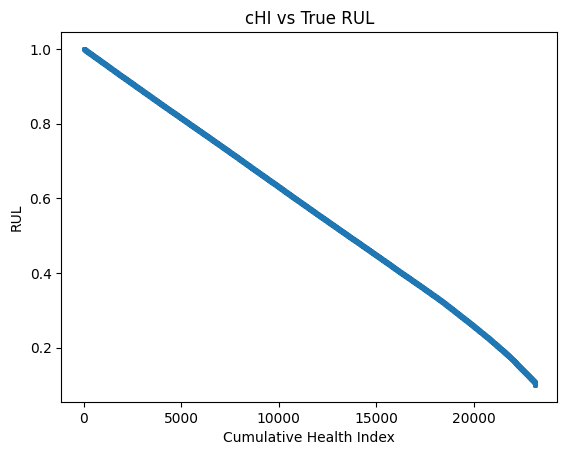

In [87]:
scaler = MinMaxScaler()

s1_norm = scaler.fit_transform(tr2[['Sensor_1']])
s4_norm = scaler.fit_transform(tr2[['Sensor_4']])

tr2['HI'] = 1 - (0.5 * s1_norm.flatten() + 0.5 * s4_norm.flatten())

tr2['cHI'] = tr2['HI'].cumsum()

X = tr2[['cHI']]
y = tr2['RUL']

model = LinearRegression()
model.fit(X, y)

tr2['RUL_pred'] = model.predict(X)

plt.figure()
plt.scatter(tr2['cHI'], tr2['RUL'], s=5)
plt.xlabel("Cumulative Health Index")
plt.ylabel("RUL")
plt.title("cHI vs True RUL")
plt.show()

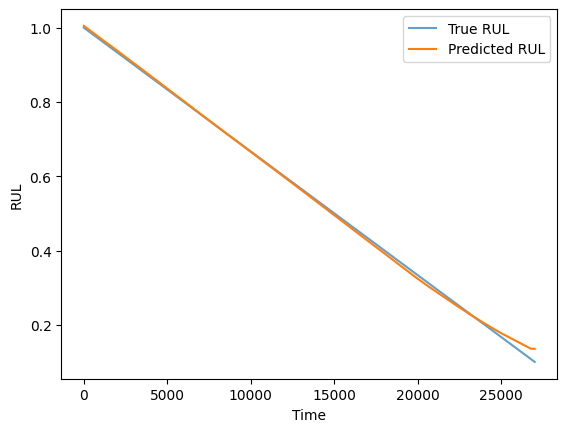

In [92]:
tr2['time'] = tr2.index

plt.figure()
plt.plot(tr2['time'], tr2['RUL'], label='True RUL', alpha = 0.7)
plt.plot(tr2['time'], tr2['RUL_pred'], label='Predicted RUL')
plt.xlabel("Time")
plt.ylabel("RUL")
plt.legend()
plt.show()

In [96]:
for s in ['Sensor_2', 'Sensor_3']:
    corr = np.corrcoef(tr2[s], tr2['RUL'])[0,1]
    print(s, corr)

Sensor_2 0.5654586106350038
Sensor_3 0.7086157136575391


In [101]:
np.corrcoef(tr2['cHI'], tr2['Sensor_2'])[0,1]

np.float64(-0.579494511094634)

In [102]:
tr2['HI1234'] = 1 - (
    0.4 * s1_norm +
    0.3 * s4_norm +
    0.2 * s2_norm +
    0.1 * s3_norm
)

tr2['cHI1234'] = tr2['HI1234'].cumsum()

X = tr2[['cHI1234']]
y = tr2['RUL']

mae_14 = mean_absolute_error(tr2['RUL'],tr2['cHI'])
mae_1234 = mean_absolute_error(tr2['RUL'], tr2['cHI1234'])
print("HI(1,4) MAE:", mae_14)
print("HI(1,2,3,4) MAE:", mae_1234)

NameError: name 's2_norm' is not defined